In [481]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.optimize import curve_fit

In [482]:
# ── Core physics ───────────────────────────────────────────────────────────────

def kron_delta(a, b):
    return 1 if a == b else 0

def element_calc(q, prob, a2, b2, a1, b1):
    return ((4 * kron_delta(a2, b2) - 1) / 3) * (
        q**2 * kron_delta(a1, a2) * kron_delta(b1, b2)
        + q*(1-q) * (prob[a2]*kron_delta(b1, b2) + prob[b2]*kron_delta(a1, a2))
        + (1-q)**2 * prob[a2] * prob[b2]
    )

def matrix_calc(q, prob):
    M = np.zeros((16, 16))
    for i, j in itertools.product(range(4), repeat=2):
        for k, l in itertools.product(range(4), repeat=2):
            M[4*i+j][4*k+l] = element_calc(q, prob, i, j, k, l)
    return M

def first_vector(prob):
    vec = np.zeros((16, 1))
    for i, j in itertools.product(range(4), repeat=2):
        vec[4*i+j] = prob[i] * prob[j] * (4*kron_delta(i, j) - 1) / 3
    return vec

def prob_list(px, py, pz):
    return [1-(px+py+pz), px, py, pz]

def calculate_frobnorm(q, prob, n_step):
    M = matrix_calc(q, prob)
    one_vec = np.ones((1, 16))
    first_vec = first_vector(prob)
    M_T = np.linalg.matrix_power(M, n_step)
    result = (one_vec @ M_T @ first_vec) / 2
    return np.sqrt(result[0][0].real)

def extreme_case(prob):
    """Extreme non-Markovian reference value = √(½·Σpᵢ²)."""
    return np.sqrt(0.5 * sum(p**2 for p in prob))

def frob_t0(prob):
    """Exact Frobenius norm at t=0, independent of q. = √((4Σpᵢ²−1)/6)."""
    return np.sqrt((4 * sum(p**2 for p in prob) - 1) / 6)


# ── Fitting models ─────────────────────────────────────────────────────────────

def exp_model(t, A, B):
    return A * np.exp(B * t)

def linear_func(q, a, b):
    return a*q + b

def quad_func(q, a, b, c):
    return a*q**2 + b*q + c

def log_quad_func(q, a, b, c):
    return np.log(np.abs(a*q**2 + b*q + c))

def log_quad_func_c1(q, a, b):
    """Quadratic: a+b+c=1 → c=1-a-b."""
    c = 1 - a - b
    return np.log(np.abs(a*q**2 + b*q + c))

def quad_func_c1(q, a, b):
    """Quadratic with constraint a+b+c=1."""
    c = 1 - a - b
    return a*q**2 + b*q + c

def log_cubic_func_c1(q, a, b, c):
    """Cubic: a+b+c+d=1 → d=1-a-b-c."""
    d = 1 - a - b - c
    return np.log(np.abs(a*q**3 + b*q**2 + c*q + d))

def log_quartic_func_c1(q, a, b, c, d):
    """Quartic: a+b+c+d+e=1 → e=1-a-b-c-d."""
    e = 1 - a - b - c - d
    return np.log(np.abs(a*q**4 + b*q**3 + c*q**2 + d*q + e))


# ── Utilities ──────────────────────────────────────────────────────────────────

def r2_score(y_data, y_fit):
    y_data, y_fit = np.array(y_data), np.array(y_fit)
    ss_res = np.sum((y_data - y_fit)**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    return 1 - ss_res / ss_tot

def get_exp_fit_params(prob, q_list, step_list):
    """Fit exp_model to frob norm for each q. Returns (amplitudes, decay_coeffs)."""
    amplitudes, decay_coeffs = [], []
    for q in q_list:
        frob = np.array([calculate_frobnorm(q, prob, t) for t in step_list])
        popt, _ = curve_fit(exp_model, step_list, frob, p0=[1, -0.1], maxfev=10000)
        amplitudes.append(popt[0])
        decay_coeffs.append(popt[1])
    return np.array(amplitudes), np.array(decay_coeffs)

def get_decay_coeffs(prob, q_list, step_list):
    """Convenience wrapper — returns only decay coefficients B."""
    _, Bs = get_exp_fit_params(prob, q_list, step_list)
    return Bs

def fit_all_models(q_arr, decay_coeffs):
    """Fit linear, quadratic, cubic, quartic log-polynomial models to decay coefficients."""
    models = {
        'Linear':        (linear_func,         [1, -0.1],        lambda p: p),
        'log Quadratic':     (log_quad_func_c1,     [1, -0.1],        lambda p: (*p, 1-p[0]-p[1])),
        'log Cubic':         (log_cubic_func_c1,    [1, -0.1, 0],     lambda p: (*p, 1-p[0]-p[1]-p[2])),
        'log Quartic':       (log_quartic_func_c1,  [1, -0.1, 0, 0],  lambda p: (*p, 1-p[0]-p[1]-p[2]-p[3])),
    }
    results = {}
    for name, (func, p0, expand) in models.items():
        try:
            popt, _ = curve_fit(func, q_arr, decay_coeffs, p0=p0, maxfev=10000)
            r2 = r2_score(decay_coeffs, func(q_arr, *popt))
            results[name] = {'func': func, 'popt': popt, 'popt_full': expand(popt), 'r2': r2}
        except Exception as e:
            results[name] = {'func': func, 'popt': None, 'popt_full': None, 'r2': np.nan, 'error': str(e)}
    return results


In [483]:
# ╔══════════════════════════════════════════════════════╗
# ║               INPUT VARIABLES                        ║
# ╚══════════════════════════════════════════════════════╝

Q_PLOT   = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.99 ,1.0]   # q values shown in frob norm plot
N_STEPS  = np.arange(0, 50)                  # time steps for all analysis
DENSE_Q  = np.linspace(0.0, 1.0, 100)          # q grid for decay coeff analysis
Q_SMOOTH = np.linspace(0.0, 1.0, 500)         # dense q grid for smooth fit curves
Q_TEST   = np.linspace(0.05, 0.95, 100)        # q values for direct fit comparison


In [484]:
from matplotlib.gridspec import GridSpec

def analyse(prob):
    """
    Full analysis for a single prob = [p0, px, py, pz].
    A fixed = frob_t0(prob) = √((4Σpᵢ²−1)/6), the exact t=0 Frobenius norm.
    Constraint: sum of coefficients = 1.
    """
    title = f'p0={prob[0]}, px={prob[1]}, py={prob[2]}, pz={prob[3]}'
    Q_EX  = 0.5
    A_fix = frob_t0(prob)
    A_ext = extreme_case(prob)

    # ── Fit exp_model for each q → get B(q) ──────────────────────────────────
    _, decay_coeffs = get_exp_fit_params(prob, DENSE_Q, N_STEPS)
    fit_results = fit_all_models(DENSE_Q, decay_coeffs)

    # ── Extract log-fit params for each order ─────────────────────────────────
    def safe_popt(name, fallback):
        res = fit_results[name]
        return res['popt'] if res['popt'] is not None else np.array(fallback)

    popt_lq  = safe_popt('log Quadratic', [1, -0.1])
    popt_lc  = safe_popt('log Cubic',     [1, -0.1, 0])
    popt_lqt = safe_popt('log Quartic',   [1, -0.1, 0, 0])

    a_lq, b_lq = popt_lq;   c_lq = 1 - a_lq - b_lq
    a_lc, b_lc, c_lc = popt_lc;   d_lc = 1 - a_lc - b_lc - c_lc
    a_lqt, b_lqt, c_lqt, d_lqt = popt_lqt;   e_lqt = 1 - a_lqt - b_lqt - c_lqt - d_lqt

    # ── Dominant eigenvalue of M for each q ──────────────────────────────────
    dominant_eigs = np.array([
        np.max(np.abs(np.linalg.eigvals(matrix_calc(q, prob))))
        for q in DENSE_Q
    ])

    # ── Build global dataset ──────────────────────────────────────────────────
    t_all, q_all, frob_all = [], [], []
    for q in Q_TEST:
        for t in N_STEPS:
            t_all.append(t); q_all.append(q)
            frob_all.append(calculate_frobnorm(q, prob, t))
    t_all = np.array(t_all); q_all = np.array(q_all); frob_all = np.array(frob_all)

    # ── Global quadratic fit ──────────────────────────────────────────────────
    def global_quad(Xdata, a, b):
        t, q = Xdata; c = 1 - a - b
        return A_fix * ((a*q**2 + b*q + c) ** t)

    popt_gq, _ = curve_fit(global_quad, (t_all, q_all), frob_all, p0=popt_lq, maxfev=100000)
    a_gq, b_gq = popt_gq;   c_gq = 1 - a_gq - b_gq
    r2_gq = r2_score(frob_all, global_quad((t_all, q_all), *popt_gq))

    # ── Global cubic fit ──────────────────────────────────────────────────────
    def global_cub(Xdata, a, b, c):
        t, q = Xdata; d = 1 - a - b - c
        return A_fix * ((a*q**3 + b*q**2 + c*q + d) ** t)

    popt_gc, _ = curve_fit(global_cub, (t_all, q_all), frob_all, p0=popt_lc, maxfev=100000)
    a_gc, b_gc, c_gc = popt_gc;   d_gc = 1 - a_gc - b_gc - c_gc
    r2_gc = r2_score(frob_all, global_cub((t_all, q_all), *popt_gc))

    # ── Global quartic fit ────────────────────────────────────────────────────
    def global_qrt(Xdata, a, b, c, d):
        t, q = Xdata; e = 1 - a - b - c - d
        return A_fix * ((a*q**4 + b*q**3 + c*q**2 + d*q + e) ** t)

    popt_gqt, _ = curve_fit(global_qrt, (t_all, q_all), frob_all, p0=popt_lqt, maxfev=100000)
    a_gqt, b_gqt, c_gqt, d_gqt = popt_gqt;   e_gqt = 1 - a_gqt - b_gqt - c_gqt - d_gqt
    r2_gqt = r2_score(frob_all, global_qrt((t_all, q_all), *popt_gqt))

    # ── Per-q R² for all models ───────────────────────────────────────────────
    exp_r2s, r2s_gq, r2s_gc, r2s_gqt = [], [], [], []
    for q in Q_TEST:
        frob   = np.array([calculate_frobnorm(q, prob, t) for t in N_STEPS])
        maxfev = 100000 if q < 0.2 else 10000
        popt_e, _ = curve_fit(exp_model, N_STEPS, frob, p0=[1, -0.1], maxfev=maxfev)
        exp_r2s.append(r2_score(frob, exp_model(N_STEPS, *popt_e)))
        lam_q  = a_gq *q**2 + b_gq *q + c_gq
        lam_c  = a_gc *q**3 + b_gc *q**2 + c_gc *q + d_gc
        lam_qt = a_gqt*q**4 + b_gqt*q**3 + c_gqt*q**2 + d_gqt*q + e_gqt
        r2s_gq.append(r2_score(frob,  A_fix * (lam_q  ** N_STEPS)))
        r2s_gc.append(r2_score(frob,  A_fix * (lam_c  ** N_STEPS)))
        r2s_gqt.append(r2_score(frob, A_fix * (lam_qt ** N_STEPS)))

    # ── Example fit at Q_EX ───────────────────────────────────────────────────
    frob_ex     = np.array([calculate_frobnorm(Q_EX, prob, t) for t in N_STEPS])
    lam_ex      = a_gq*Q_EX**2 + b_gq*Q_EX + c_gq
    frob_ex_fit = A_fix * (lam_ex ** N_STEPS)
    r2_ex       = r2_score(frob_ex, frob_ex_fit)

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 30))
    fig.suptitle(title, fontsize=14)
    gs = GridSpec(5, 6, figure=fig, hspace=0.5, wspace=0.4)

    ax_frob  = fig.add_subplot(gs[0, :])
    ax_decay = fig.add_subplot(gs[1, :])
    ax_ex    = fig.add_subplot(gs[2, :3])
    ax_r2cmp = fig.add_subplot(gs[2, 3:])
    ax_lam   = fig.add_subplot(gs[3, :3])
    ax_abc   = fig.add_subplot(gs[3, 3:])
    ax_cub   = fig.add_subplot(gs[4, :3])
    ax_qrt   = fig.add_subplot(gs[4, 3:])

    # Row 1: Frobenius norm
    for q in Q_PLOT:
        ax_frob.plot(N_STEPS, [calculate_frobnorm(q, prob, t) for t in N_STEPS], label=f'q={q}')
    ax_frob.axhline(A_fix, color='red', linestyle='--',
                    label=f'$\\sqrt{{(4\\Sigma p_i^2-1)/6}}$ = {A_fix:.4f}  (t=0 frob)')
    ax_frob.axhline(A_ext, color='purple', linestyle=':',
                    label=f'$\\sqrt{{\\frac{{1}}{{2}}\\Sigma p_i^2}}$ = {A_ext:.4f}  (extreme case)')
    ax_frob.set_xlabel('Step'); ax_frob.set_ylabel('Frobenius Norm')
    ax_frob.set_title('Frobenius Norm vs Steps')
    ax_frob.set_ylim(0, 1); ax_frob.legend(fontsize=8)

    # Row 2: Decay coefficients B(q)
    ax_decay.scatter(DENSE_Q, decay_coeffs, s=20, zorder=5, label='data')
    for name, res in fit_results.items():
        if res['popt'] is not None:
            ax_decay.plot(Q_SMOOTH, res['func'](Q_SMOOTH, *res['popt']),
                          label=f"{name}  R²={res['r2']:.4f}")
    ax_decay.set_xlabel('q'); ax_decay.set_ylabel('Decay coefficient B')
    ax_decay.set_title('Model fits on B(q)  [constraint at q=1]')
    ax_decay.legend(fontsize=8)

    # Row 3 left: Example fit
    ax_ex.scatter(N_STEPS, frob_ex, s=10, label='data', zorder=5)
    ax_ex.plot(N_STEPS, frob_ex_fit, color='red', label=f'A·(aq²+bq+c)^t  R²={r2_ex:.5f}')
    ax_ex.set_xlabel('Step'); ax_ex.set_ylabel('Frobenius Norm')
    ax_ex.set_title(f'Example fit at q={Q_EX}  (quadratic global)')
    ax_ex.legend(fontsize=8)

    # Row 3 right: Per-q R²
    ax_r2cmp.plot(Q_TEST, exp_r2s,  marker='o', label='exp per-q')
    ax_r2cmp.plot(Q_TEST, r2s_gq,   marker='s', label=f'global quadratic  (R²={r2_gq:.4f})')
    ax_r2cmp.plot(Q_TEST, r2s_gc,   marker='^', label=f'global cubic       (R²={r2_gc:.4f})')
    ax_r2cmp.plot(Q_TEST, r2s_gqt,  marker='D', label=f'global quartic     (R²={r2_gqt:.4f})')
    ax_r2cmp.set_xlabel('q'); ax_r2cmp.set_ylabel('R²')
    ax_r2cmp.set_title('Fit quality per q')
    ax_r2cmp.legend(fontsize=7)

    # Row 4 left: λ(q) comparison
    actual_lam = np.exp(decay_coeffs)
    lam_gq_arr = a_gq*DENSE_Q**2 + b_gq*DENSE_Q + c_gq
    lam_lq_arr = np.abs(a_lq*DENSE_Q**2 + b_lq*DENSE_Q + c_lq)
    ax_lam.scatter(DENSE_Q, dominant_eigs, s=20, zorder=5, marker='^', color='green', label='dominant eig of M')
    ax_lam.scatter(DENSE_Q, actual_lam, s=20, zorder=5, color='black', label='λ = e^B (exp fit)')
    ax_lam.plot(DENSE_Q, lam_gq_arr, label=f'Global quadratic  (R²={r2_gq:.4f})')
    ax_lam.plot(DENSE_Q, lam_lq_arr, linestyle='--', label='Log-quadratic fit')
    ax_lam.set_xlabel('q'); ax_lam.set_ylabel('λ(q)')
    ax_lam.set_title('Eigenvalue λ(q)  [a+b+c=1]'); ax_lam.legend(fontsize=8)

    # Row 4 right: Quadratic coefficients
    x = np.arange(3); w = 0.35
    ax_abc.bar(x - w/2, [a_gq, b_gq, c_gq], w, label='Global fit',  color='steelblue')
    ax_abc.bar(x + w/2, [a_lq, b_lq, c_lq], w, label='Log fit',     color='red', alpha=0.7)
    ax_abc.set_xticks(x); ax_abc.set_xticklabels(['a', 'b', 'c'])
    ax_abc.set_title('Quadratic coefficients  [a+b+c=1]'); ax_abc.legend(fontsize=8)

    # Row 5 left: Cubic coefficients
    x = np.arange(4)
    ax_cub.bar(x - w/2, [a_gc, b_gc, c_gc, d_gc], w, label='Global fit', color='steelblue')
    ax_cub.bar(x + w/2, [a_lc, b_lc, c_lc, d_lc], w, label='Log fit',   color='red', alpha=0.7)
    ax_cub.set_xticks(x); ax_cub.set_xticklabels(['a', 'b', 'c', 'd'])
    ax_cub.set_title('Cubic coefficients  [a+b+c+d=1]'); ax_cub.legend(fontsize=8)

    # Row 5 right: Quartic coefficients
    x = np.arange(5)
    ax_qrt.bar(x - w/2, [a_gqt, b_gqt, c_gqt, d_gqt, e_gqt], w, label='Global fit', color='steelblue')
    ax_qrt.bar(x + w/2, [a_lqt, b_lqt, c_lqt, d_lqt, e_lqt], w, label='Log fit',    color='red', alpha=0.7)
    ax_qrt.set_xticks(x); ax_qrt.set_xticklabels(['a', 'b', 'c', 'd', 'e'])
    ax_qrt.set_title('Quartic coefficients  [a+b+c+d+e=1]'); ax_qrt.legend(fontsize=8)

    plt.show()

    print(f"\nProbabilities: p0={prob[0]},  px={prob[1]},  py={prob[2]},  pz={prob[3]}")
    print(f"A (t=0 frob norm)  = {A_fix:.8f}   [√((4Σpᵢ²−1)/6)]")
    print(f"extreme_case       = {A_ext:.8f}   [√(½Σpᵢ²)]")
    print(f"\n  Global quadratic  [a+b+c=1]:      a={a_gq:.6f},  b={b_gq:.6f},  c={c_gq:.6f}              R²={r2_gq:.6f}")
    print(f"  Global cubic      [a+b+c+d=1]:    a={a_gc:.6f},  b={b_gc:.6f},  c={c_gc:.6f},  d={d_gc:.6f}   R²={r2_gc:.6f}")
    print(f"  Global quartic    [a+b+c+d+e=1]:  a={a_gqt:.6f},  b={b_gqt:.6f},  c={c_gqt:.6f},  d={d_gqt:.6f},  e={e_gqt:.6f}   R²={r2_gqt:.6f}")
    print(f"\n  B(q) log-fit R²:")
    for name, res in fit_results.items():
        print(f"    {name:<14}  R²={res['r2']:.6f}")

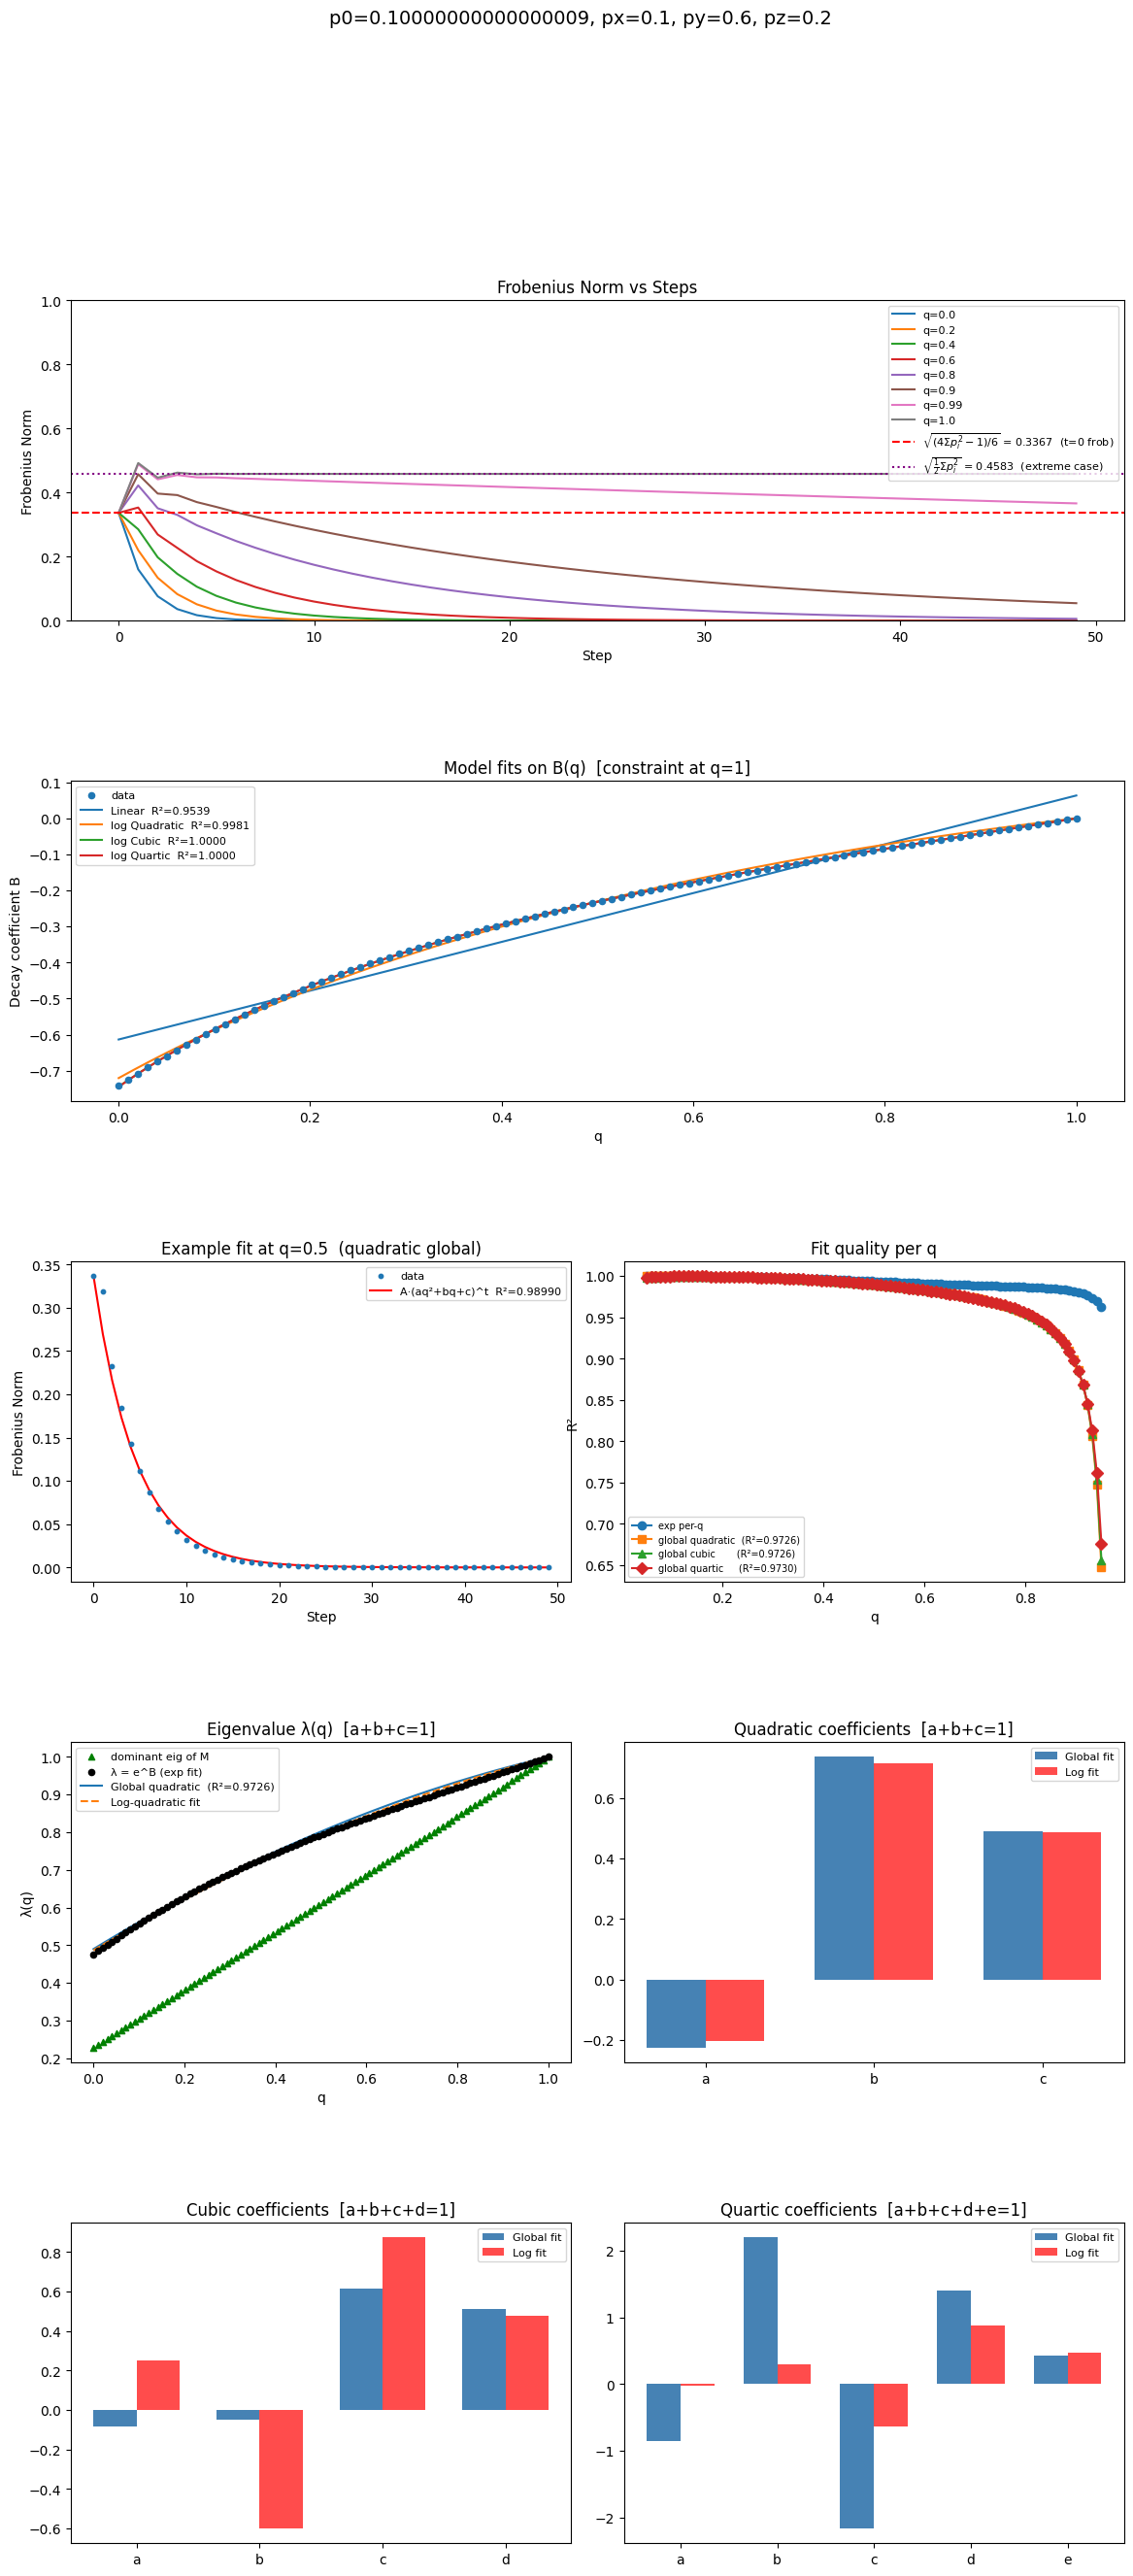


Probabilities: p0=0.10000000000000009,  px=0.1,  py=0.6,  pz=0.2
A (t=0 frob norm)  = 0.33665016   [√((4Σpᵢ²−1)/6)]
extreme_case       = 0.45825757   [√(½Σpᵢ²)]

  Global quadratic  [a+b+c=1]:      a=-0.227292,  b=0.737506,  c=0.489786              R²=0.972573
  Global cubic      [a+b+c+d=1]:    a=-0.082873,  b=-0.047397,  c=0.617246,  d=0.513025   R²=0.972641
  Global quartic    [a+b+c+d+e=1]:  a=-0.854279,  b=2.198690,  c=-2.166913,  d=1.395443,  e=0.427058   R²=0.973019

  B(q) log-fit R²:
    Linear          R²=0.953910
    log Quadratic   R²=0.998066
    log Cubic       R²=0.999991
    log Quartic     R²=0.999992


In [485]:
# ── Run analysis for a specific prob list ─────────────────────────────────────

analyse(prob_list(0.1, 0.6,0.2))


In [486]:
import os

def plot_summary(prob, save_dir='.', Q_EX=0.5, n_leading=3):
    """
    Produces and saves a summary figure with:
      Row 1 — Frobenius norm vs steps
      Row 2 — Model fit on B(q)
      Row 3 — Fit quality per q (left) | Example fit (right)
      Row 4 — Three leading eigenvalues: |λ|, Re(λ), Im(λ)
    A = frob_t0(prob) = √((4Σpᵢ²−1)/6).
    Saved as <save_dir>/<title>.png
    """
    p = [round(x, 4) for x in prob]
    title = f'p0={p[0]}_px={p[1]}_py={p[2]}_pz={p[3]}'
    A_fix = frob_t0(prob)
    A_ext = extreme_case(prob)

    _, decay_coeffs = get_exp_fit_params(prob, DENSE_Q, N_STEPS)
    fit_results = fit_all_models(DENSE_Q, decay_coeffs)

    popt_lq  = fit_results['log Quadratic']['popt'] if fit_results['log Quadratic']['popt'] is not None else np.array([1, -0.1])
    popt_lqt = fit_results['log Quartic']['popt']   if fit_results['log Quartic']['popt']   is not None else np.array([1, -0.1, 0, 0])

    t_all, q_all, frob_all = [], [], []
    for q in Q_TEST:
        for t in N_STEPS:
            t_all.append(t); q_all.append(q)
            frob_all.append(calculate_frobnorm(q, prob, t))
    t_all = np.array(t_all); q_all = np.array(q_all); frob_all = np.array(frob_all)

    def global_quad(Xdata, a, b):
        t, q = Xdata; c = 1 - a - b
        return A_fix * ((a*q**2 + b*q + c) ** t)

    def global_qrt(Xdata, a, b, c, d):
        t, q = Xdata; e = 1 - a - b - c - d
        return A_fix * ((a*q**4 + b*q**3 + c*q**2 + d*q + e) ** t)

    popt_gq, _ = curve_fit(global_quad, (t_all, q_all), frob_all, p0=popt_lq,  maxfev=100000)
    a_gq, b_gq = popt_gq; c_gq = 1 - a_gq - b_gq
    r2_gq = r2_score(frob_all, global_quad((t_all, q_all), *popt_gq))

    popt_gqt, _ = curve_fit(global_qrt, (t_all, q_all), frob_all, p0=popt_lqt, maxfev=100000)
    a_gqt, b_gqt, c_gqt, d_gqt = popt_gqt; e_gqt = 1 - a_gqt - b_gqt - c_gqt - d_gqt
    r2_gqt = r2_score(frob_all, global_qrt((t_all, q_all), *popt_gqt))

    exp_r2s, poly_r2s = [], []
    for q in Q_TEST:
        frob   = np.array([calculate_frobnorm(q, prob, t) for t in N_STEPS])
        maxfev = 100000 if q < 0.2 else 10000
        popt_e, _ = curve_fit(exp_model, N_STEPS, frob, p0=[1, -0.1], maxfev=maxfev)
        exp_r2s.append(r2_score(frob, exp_model(N_STEPS, *popt_e)))
        lam_qt = a_gqt*q**4 + b_gqt*q**3 + c_gqt*q**2 + d_gqt*q + e_gqt
        poly_r2s.append(r2_score(frob, A_fix * (lam_qt ** N_STEPS)))

    frob_ex     = np.array([calculate_frobnorm(Q_EX, prob, t) for t in N_STEPS])
    lam_ex      = a_gqt*Q_EX**4 + b_gqt*Q_EX**3 + c_gqt*Q_EX**2 + d_gqt*Q_EX + e_gqt
    frob_ex_fit = A_fix * (lam_ex ** N_STEPS)
    r2_ex       = r2_score(frob_ex, frob_ex_fit)

    eig_abs  = np.zeros((len(DENSE_Q), n_leading))
    eig_real = np.zeros((len(DENSE_Q), n_leading))
    eig_imag = np.zeros((len(DENSE_Q), n_leading))
    for i, q in enumerate(DENSE_Q):
        eigs = np.linalg.eigvals(matrix_calc(q, prob))
        idx  = np.argsort(np.abs(eigs))[::-1][:n_leading]
        eig_abs[i]  = np.abs(eigs[idx])
        eig_real[i] = eigs[idx].real
        eig_imag[i] = eigs[idx].imag

    fig = plt.figure(figsize=(14, 24))
    fig.suptitle(title.replace('_', '  '), fontsize=13)
    gs = GridSpec(4, 6, figure=fig, hspace=0.5, wspace=0.4)

    ax_frob  = fig.add_subplot(gs[0, :])
    ax_decay = fig.add_subplot(gs[1, :])
    ax_r2cmp = fig.add_subplot(gs[2, :3])
    ax_ex    = fig.add_subplot(gs[2, 3:])
    ax_eabs  = fig.add_subplot(gs[3, :2])
    ax_ereal = fig.add_subplot(gs[3, 2:4])
    ax_eimag = fig.add_subplot(gs[3, 4:])

    for q in Q_PLOT:
        ax_frob.plot(N_STEPS, [calculate_frobnorm(q, prob, t) for t in N_STEPS], label=f'q={q}')
    ax_frob.axhline(A_fix, color='red',    linestyle='--',
                    label=f'$\\sqrt{{(4\\Sigma p_i^2-1)/6}}$ = {A_fix:.4f}  (t=0 frob)')
    ax_frob.axhline(A_ext, color='purple', linestyle=':',
                    label=f'$\\sqrt{{\\frac{{1}}{{2}}\\Sigma p_i^2}}$ = {A_ext:.4f}  (extreme case)')
    ax_frob.set_xlabel('Step'); ax_frob.set_ylabel('Frobenius Norm')
    ax_frob.set_title('Frobenius Norm vs Steps')
    ax_frob.set_ylim(0, 1); ax_frob.legend(fontsize=8)

    ax_decay.scatter(DENSE_Q, decay_coeffs, s=20, zorder=5, label='data')
    for name, res in fit_results.items():
        if res['popt'] is not None:
            ax_decay.plot(Q_SMOOTH, res['func'](Q_SMOOTH, *res['popt']),
                          label=f"{name}  R²={res['r2']:.4f}")
    ax_decay.set_xlabel('q'); ax_decay.set_ylabel('B(q)')
    ax_decay.set_title('Model fits on B(q)  [constraint at q=1]')
    ax_decay.legend(fontsize=8)

    ax_r2cmp.plot(Q_TEST, exp_r2s,  marker='o', label='exp per-q')
    ax_r2cmp.plot(Q_TEST, poly_r2s, marker='s', label=f'global quartic  (R²={r2_gqt:.4f})')
    ax_r2cmp.set_xlabel('q'); ax_r2cmp.set_ylabel('R²')
    ax_r2cmp.set_title('Fit quality per q'); ax_r2cmp.legend(fontsize=8)

    ax_ex.scatter(N_STEPS, frob_ex, s=10, label='data', zorder=5)
    ax_ex.plot(N_STEPS, frob_ex_fit, color='red', label=f'A·λ(q)^t  R²={r2_ex:.5f}')
    ax_ex.set_xlabel('Step'); ax_ex.set_ylabel('Frobenius Norm')
    ax_ex.set_title(f'Example fit at q={Q_EX}  (quartic global)'); ax_ex.legend(fontsize=8)

    colors = ['steelblue', 'orange', 'green']
    for k in range(n_leading):
        ax_eabs.plot(DENSE_Q,  eig_abs[:, k],  color=colors[k], label=f'|λ_{k+1}|')
        ax_ereal.plot(DENSE_Q, eig_real[:, k], color=colors[k], label=f'Re(λ_{k+1})')
        ax_eimag.plot(DENSE_Q, eig_imag[:, k], color=colors[k], label=f'Im(λ_{k+1})')
    for ax, ylabel, t_str in zip(
        [ax_eabs, ax_ereal, ax_eimag],
        ['|λ|', 'Re(λ)', 'Im(λ)'],
        ['|λ| — top 3 eigenvalues', 'Re(λ)', 'Im(λ)']
    ):
        ax.set_xlabel('q'); ax.set_ylabel(ylabel); ax.set_title(t_str)
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.legend(fontsize=8)

    os.makedirs(save_dir, exist_ok=True)
    filepath = os.path.join(save_dir, f'{title}.png')
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filepath}")

In [497]:
print( 0.1 ** 2 + 0.3 **2 + 0.5 ** 2 + (0.1 **2))

print( 1 - )

0.36


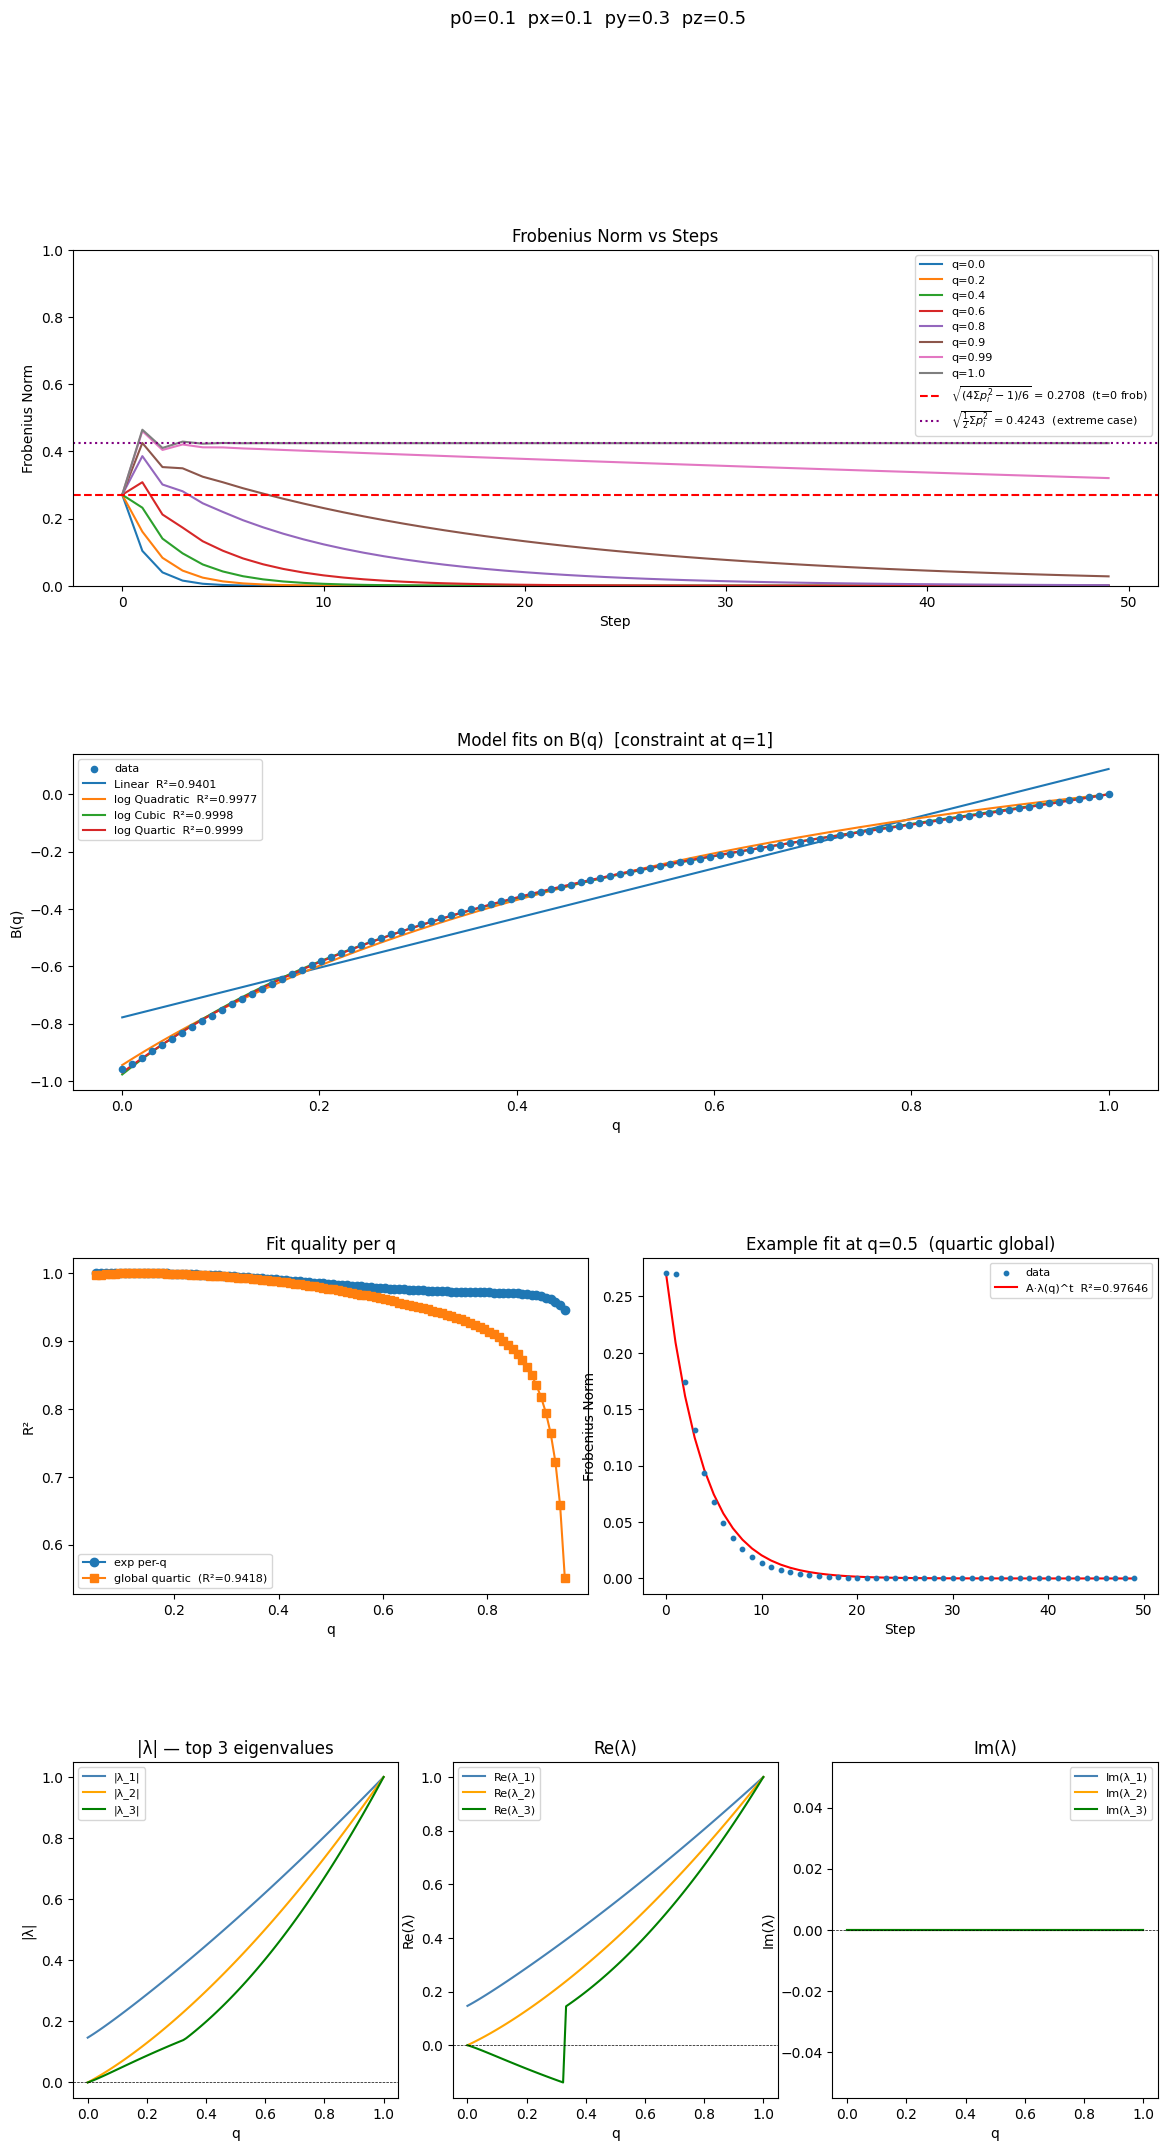

Saved: non_markovian_plots/p0=0.1_px=0.1_py=0.3_pz=0.5.png


In [496]:
plot_summary(prob_list(0.1,0.1,0.5), "non_markovian_1qubit_plots")

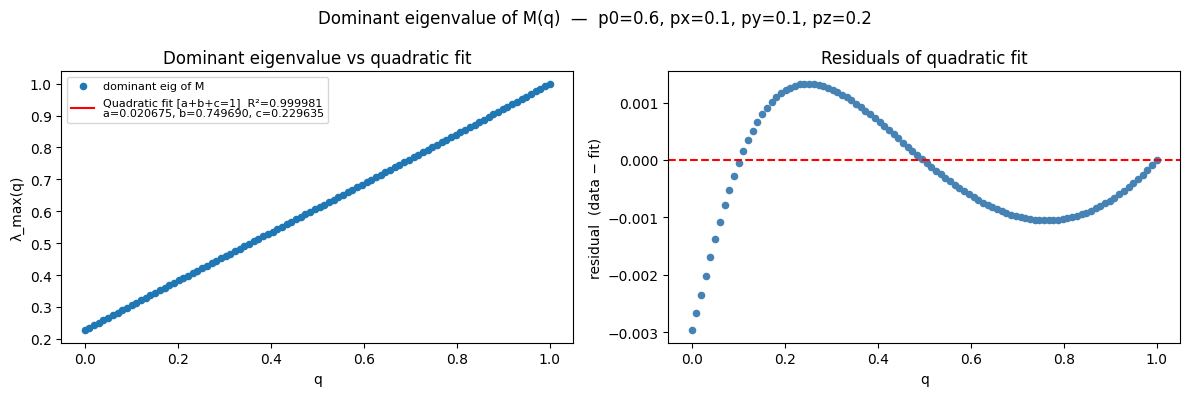


Dominant eigenvalue quadratic fit [a+b+c=1]:  a=0.020675,  b=0.749690,  c=0.229635
R² = 0.99998106
Max residual: 2.97e-03
Mean absolute residual: 8.30e-04


In [488]:
def analyse_dominant_eig(prob):
    """
    Checks whether the dominant eigenvalue of M(q) is well-approximated by a quadratic in q.
    Fits aq²+bq+c directly to the dominant eigenvalues with constraint a+b+c=1 (λ(1)=1).
    """
    title = f'p0={prob[0]}, px={prob[1]}, py={prob[2]}, pz={prob[3]}'

    # Compute dominant eigenvalue of M for each q
    dominant_eigs = np.array([
        np.max(np.abs(np.linalg.eigvals(matrix_calc(q, prob))))
        for q in DENSE_Q
    ])

    # Fit constrained quadratic (a+b+c=1) directly to dominant eigenvalues
    popt_quad, _ = curve_fit(quad_func_c1, DENSE_Q, dominant_eigs, p0=[0, -0.5], maxfev=10000)
    a_q, b_q = popt_quad
    c_q = 1 - a_q - b_q
    quad_fit  = quad_func_c1(DENSE_Q, *popt_quad)
    r2_quad   = r2_score(dominant_eigs, quad_fit)
    residuals = dominant_eigs - quad_fit

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Dominant eigenvalue of M(q)  —  {title}', fontsize=12)

    ax1.scatter(DENSE_Q, dominant_eigs, s=20, zorder=5, label='dominant eig of M')
    ax1.plot(DENSE_Q, quad_fit, color='red',
             label=f'Quadratic fit [a+b+c=1]  R²={r2_quad:.6f}\na={a_q:.6f}, b={b_q:.6f}, c={c_q:.6f}')
    ax1.set_xlabel('q')
    ax1.set_ylabel('λ_max(q)')
    ax1.set_title('Dominant eigenvalue vs quadratic fit')
    ax1.legend(fontsize=8)

    ax2.scatter(DENSE_Q, residuals, s=20, color='steelblue')
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel('q')
    ax2.set_ylabel('residual  (data − fit)')
    ax2.set_title('Residuals of quadratic fit')

    plt.tight_layout()
    plt.show()

    print(f"\nDominant eigenvalue quadratic fit [a+b+c=1]:  a={a_q:.6f},  b={b_q:.6f},  c={c_q:.6f}")
    print(f"R² = {r2_quad:.8f}")
    print(f"Max residual: {np.max(np.abs(residuals)):.2e}")
    print(f"Mean absolute residual: {np.mean(np.abs(residuals)):.2e}")


analyse_dominant_eig(prob_list(0.1, 0.1, 0.2))


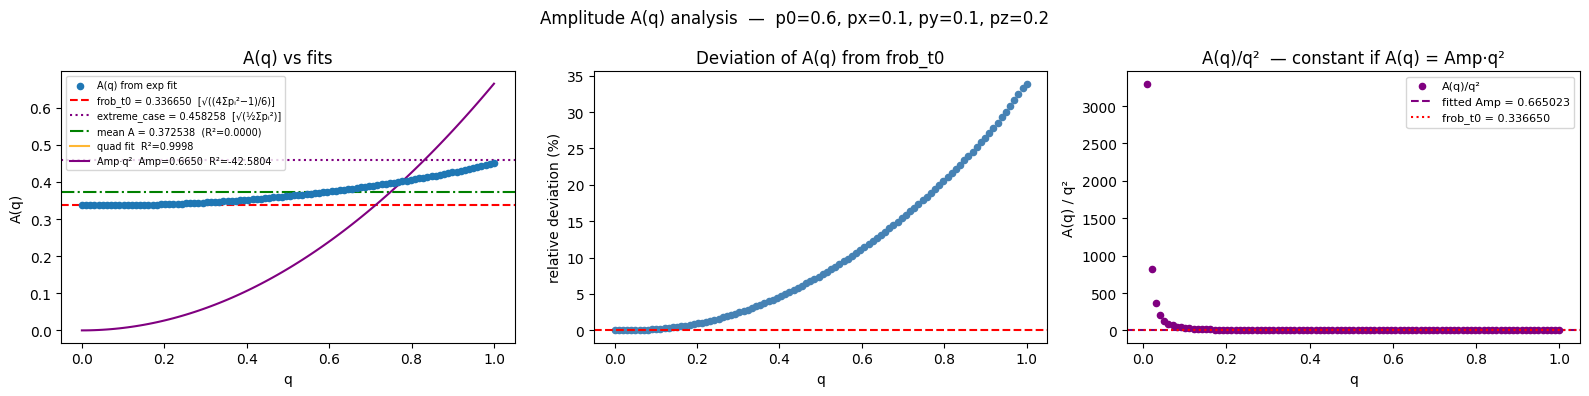


frob_t0(prob)  = √((4Σpᵢ²−1)/6) = 0.33665016  ← correct amplitude
extreme_case   = √(½Σpᵢ²)        = 0.45825757
mean A(q)      = 0.37253810   std = 3.39e-02  (9.1051%)
fitted Amp     = 0.66502303   R²(Amp·q²) = -42.580418
Δ (Amp - frob_t0) = +3.28e-01  (+97.5413%)

R² (constant):  0.000000
R² (quad fit):  0.999800
R² (Amp·q²):    -42.580418

A(q)/q² stats (q>0):  mean=54.582049,  std=3.41e+02,  min=0.450777,  max=3299.546511


In [489]:
def analyse_amplitude(prob):
    """
    Checks whether the fitted amplitude A(q) is constant with respect to q,
    and compares it to frob_t0(prob) (correct t=0 value) and extreme_case(prob).
    Also fits A(q) = Amp * q**2 and checks if Amp is constant.
    """
    title = f'p0={prob[0]}, px={prob[1]}, py={prob[2]}, pz={prob[3]}'

    amplitudes, _ = get_exp_fit_params(prob, DENSE_Q, N_STEPS)
    correct_val = frob_t0(prob)
    extreme_val = extreme_case(prob)

    A_mean   = np.mean(amplitudes)
    A_std    = np.std(amplitudes)

    popt_quad, _ = curve_fit(quad_func, DENSE_Q, amplitudes, p0=[0, 0, A_mean], maxfev=10000)
    quad_fit  = quad_func(DENSE_Q, *popt_quad)
    r2_quad   = r2_score(amplitudes, quad_fit)
    r2_const  = r2_score(amplitudes, np.full_like(amplitudes, A_mean))

    def amp_q2(q, Amp):
        return Amp * q**2

    popt_q2, _ = curve_fit(amp_q2, DENSE_Q, amplitudes, p0=[correct_val], maxfev=10000)
    Amp_fit   = popt_q2[0]
    q2_fit    = amp_q2(DENSE_Q, Amp_fit)
    r2_q2     = r2_score(amplitudes, q2_fit)

    mask      = DENSE_Q > 0
    amp_ratio = amplitudes[mask] / DENSE_Q[mask]**2
    rel_dev   = (amplitudes - correct_val) / correct_val

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Amplitude A(q) analysis  —  {title}', fontsize=12)
    ax1, ax2, ax3 = axes

    ax1.scatter(DENSE_Q, amplitudes, s=20, zorder=5, label='A(q) from exp fit')
    ax1.axhline(correct_val, color='red',    linestyle='--',
                label=f'frob_t0 = {correct_val:.6f}  [√((4Σpᵢ²−1)/6)]')
    ax1.axhline(extreme_val, color='purple', linestyle=':',
                label=f'extreme_case = {extreme_val:.6f}  [√(½Σpᵢ²)]')
    ax1.axhline(A_mean,      color='green',  linestyle='-.',
                label=f'mean A = {A_mean:.6f}  (R²={r2_const:.4f})')
    ax1.plot(DENSE_Q, quad_fit, color='orange', alpha=0.8, label=f'quad fit  R²={r2_quad:.4f}')
    ax1.plot(DENSE_Q, q2_fit,   color='purple', label=f'Amp·q²  Amp={Amp_fit:.4f}  R²={r2_q2:.4f}')
    ax1.set_xlabel('q'); ax1.set_ylabel('A(q)')
    ax1.set_title('A(q) vs fits'); ax1.legend(fontsize=7)

    ax2.scatter(DENSE_Q, rel_dev * 100, s=20, color='steelblue')
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel('q'); ax2.set_ylabel('relative deviation (%)')
    ax2.set_title('Deviation of A(q) from frob_t0')

    ax3.scatter(DENSE_Q[mask], amp_ratio, s=20, color='purple', label='A(q)/q²')
    ax3.axhline(Amp_fit,     color='purple', linestyle='--', label=f'fitted Amp = {Amp_fit:.6f}')
    ax3.axhline(correct_val, color='red',    linestyle=':',  label=f'frob_t0 = {correct_val:.6f}')
    ax3.set_xlabel('q'); ax3.set_ylabel('A(q) / q²')
    ax3.set_title('A(q)/q²  — constant if A(q) = Amp·q²'); ax3.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\nfrob_t0(prob)  = √((4Σpᵢ²−1)/6) = {correct_val:.8f}  ← correct amplitude")
    print(f"extreme_case   = √(½Σpᵢ²)        = {extreme_val:.8f}")
    print(f"mean A(q)      = {A_mean:.8f}   std = {A_std:.2e}  ({100*A_std/A_mean:.4f}%)")
    print(f"fitted Amp     = {Amp_fit:.8f}   R²(Amp·q²) = {r2_q2:.6f}")
    print(f"Δ (Amp - frob_t0) = {Amp_fit - correct_val:+.2e}  ({100*(Amp_fit-correct_val)/correct_val:+.4f}%)")
    print(f"\nR² (constant):  {r2_const:.6f}")
    print(f"R² (quad fit):  {r2_quad:.6f}")
    print(f"R² (Amp·q²):    {r2_q2:.6f}")
    print(f"\nA(q)/q² stats (q>0):  mean={np.mean(amp_ratio):.6f},  std={np.std(amp_ratio):.2e},  "
          f"min={np.min(amp_ratio):.6f},  max={np.max(amp_ratio):.6f}")


analyse_amplitude(prob_list(0.1, 0.1, 0.2))


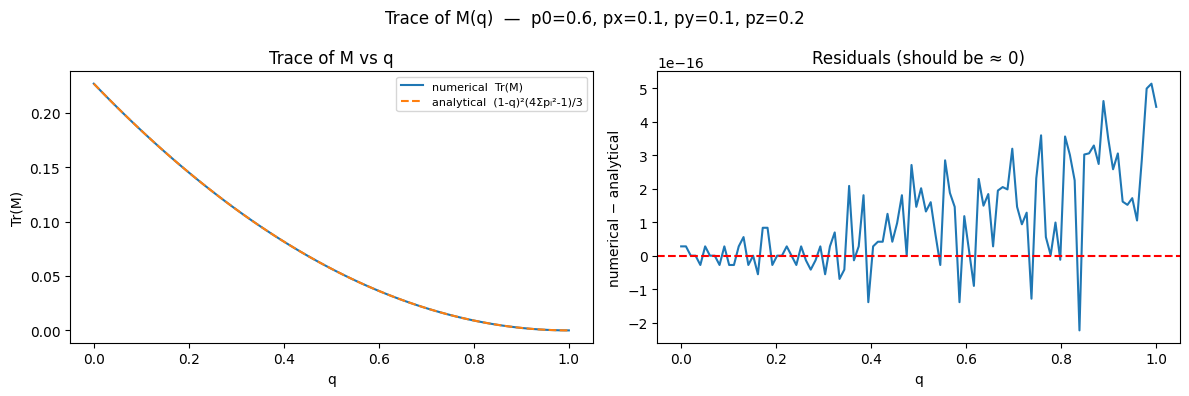


Analytical formula:  Tr(M) = (1-q)² · (4·Σpᵢ² - 1) / 3
  Σpᵢ²  = 0.420000
  4Σpᵢ²-1 = 0.680000

  Tr(M) at q=0: 0.226667
  Tr(M) at q=1: 0.000000  (must be 0)
  Max residual: 5.13e-16


In [490]:
def trace_M_analytical(q, prob):
    """Tr(M) = (1-q)^2 * (4*Σpᵢ² - 1) / 3"""
    return (1 - q)**2 * (4 * sum(p**2 for p in prob) - 1) / 3

def analyse_trace(prob):
    title = f'p0={prob[0]}, px={prob[1]}, py={prob[2]}, pz={prob[3]}'

    trace_numerical   = np.array([np.trace(matrix_calc(q, prob)) for q in DENSE_Q])
    trace_analytical  = np.array([trace_M_analytical(q, prob) for q in DENSE_Q])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Trace of M(q)  —  {title}', fontsize=12)

    ax1.plot(DENSE_Q, trace_numerical,  label='numerical  Tr(M)')
    ax1.plot(DENSE_Q, trace_analytical, linestyle='--', label='analytical  (1-q)²(4Σpᵢ²-1)/3')
    ax1.set_xlabel('q')
    ax1.set_ylabel('Tr(M)')
    ax1.set_title('Trace of M vs q')
    ax1.legend(fontsize=8)

    residuals = trace_numerical - trace_analytical
    ax2.plot(DENSE_Q, residuals)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel('q')
    ax2.set_ylabel('numerical − analytical')
    ax2.set_title('Residuals (should be ≈ 0)')

    plt.tight_layout()
    plt.show()

    sum_p2 = sum(p**2 for p in prob)
    print(f"\nAnalytical formula:  Tr(M) = (1-q)² · (4·Σpᵢ² - 1) / 3")
    print(f"  Σpᵢ²  = {sum_p2:.6f}")
    print(f"  4Σpᵢ²-1 = {4*sum_p2 - 1:.6f}")
    print(f"\n  Tr(M) at q=0: {trace_M_analytical(0, prob):.6f}")
    print(f"  Tr(M) at q=1: {trace_M_analytical(1, prob):.6f}  (must be 0)")
    print(f"  Max residual: {np.max(np.abs(residuals)):.2e}")


analyse_trace(prob_list(0.1, 0.1, 0.2))


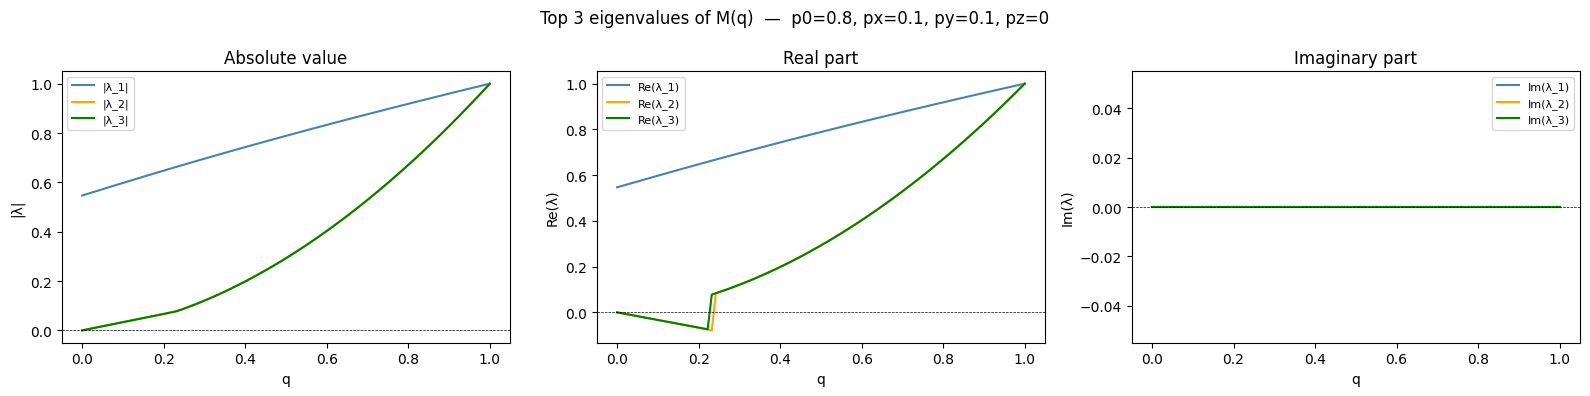


Top 3 eigenvalues at key q values:
      q |      |λ_1|  Re  Im |      |λ_2|  Re  Im |      |λ_3|  Re  Im
  --------------------------------------------------------------------------------
   0.00 | 0.546667  +0.546667  +0.000000  |  0.000000  -0.000000  +0.000000  |  0.000000  +0.000000  +0.000000
   0.25 | 0.673124  +0.673124  +0.000000  |  0.089860  +0.089860  +0.000000  |  0.089742  +0.089742  +0.000000
   0.50 | 0.786239  +0.786239  +0.000000  |  0.288149  +0.288149  +0.000000  |  0.287320  +0.287320  +0.000000
   0.75 | 0.896267  +0.896267  +0.000000  |  0.594612  +0.594612  +0.000000  |  0.594182  +0.594182  +0.000000
   1.00 | 1.000000  +1.000000  +0.000000  |  1.000000  +1.000000  +0.000000  |  1.000000  +1.000000  +0.000000


In [491]:
def analyse_leading_eigenvalues(prob, n_leading=3):
    """
    Plots the n_leading largest eigenvalues of M(q) (by absolute value) as a function of q.
    Shows |λ|, Re(λ), and Im(λ) separately.
    """
    title = f'p0={prob[0]}, px={prob[1]}, py={prob[2]}, pz={prob[3]}'

    # For each q, compute all eigenvalues and pick the n_leading largest by |λ|
    eig_abs  = np.zeros((len(DENSE_Q), n_leading))
    eig_real = np.zeros((len(DENSE_Q), n_leading))
    eig_imag = np.zeros((len(DENSE_Q), n_leading))

    for i, q in enumerate(DENSE_Q):
        eigs = np.linalg.eigvals(matrix_calc(q, prob))
        idx  = np.argsort(np.abs(eigs))[::-1][:n_leading]   # top n by |λ|
        eig_abs[i]  = np.abs(eigs[idx])
        eig_real[i] = eigs[idx].real
        eig_imag[i] = eigs[idx].imag

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Top {n_leading} eigenvalues of M(q)  —  {title}', fontsize=12)
    ax1, ax2, ax3 = axes

    colors = ['steelblue', 'orange', 'green']
    for k in range(n_leading):
        ax1.plot(DENSE_Q, eig_abs[:, k],  color=colors[k], label=f'|λ_{k+1}|')
        ax2.plot(DENSE_Q, eig_real[:, k], color=colors[k], label=f'Re(λ_{k+1})')
        ax3.plot(DENSE_Q, eig_imag[:, k], color=colors[k], label=f'Im(λ_{k+1})')

    for ax, ylabel, title_str in zip(
        [ax1, ax2, ax3],
        ['|λ|', 'Re(λ)', 'Im(λ)'],
        ['Absolute value', 'Real part', 'Imaginary part']
    ):
        ax.set_xlabel('q')
        ax.set_ylabel(ylabel)
        ax.set_title(title_str)
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Print values at key q points
    print(f"\nTop {n_leading} eigenvalues at key q values:")
    print(f"  {'q':>5} | " + " | ".join(f"{'|λ_'+str(k+1)+'|':>10}  Re  Im" for k in range(n_leading)))
    print(f"  {'-'*80}")
    for q_val in [0.0, 0.25, 0.5, 0.75, 1.0]:
        idx   = np.argmin(np.abs(DENSE_Q - q_val))
        parts = "  |  ".join(
            f"{eig_abs[idx,k]:>8.6f}  {eig_real[idx,k]:>+8.6f}  {eig_imag[idx,k]:>+8.6f}"
            for k in range(n_leading)
        )
        print(f"  {q_val:>5.2f} | {parts}")


analyse_leading_eigenvalues(prob_list(0.1, 0.1, 0))
